In [1]:
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

# --- 1. Поставување на Selenium WebDriver ---
options = Options()
options.add_argument("--headless")  # Работи во позадина
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--log-level=3") # Ја намалува бучавата во конзолата
service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://quotes.toscrape.com/scroll"
all_quotes_data = []

print("Selenium WebDriver е стартуван...")

try:
    driver.get(url)
    print(f"Ја вчитувам страницата: {url}")
    
    # --- 2. Логика за бесконечно скролање ---
    last_height = driver.execute_script("return document.body.scrollHeight")
    
    while True:
        # Скролни до дното на страницата
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        
        # Почекај новите податоци да се вчитаат
        # За оваа страна, 1.5 секунда е доволно
        time.sleep(1.5) 
        
        # Пресметај ја новата висина и спореди ја со старата
        new_height = driver.execute_script("return document.body.scrollHeight")
        
        if new_height == last_height:
            print("Стигнавме до крајот. Нема повеќе цитати.")
            break # Излези од циклусот
        
        last_height = new_height
        print("Скролам за повеќе цитати...")

    # --- 3. Собирање на податоците ОТКАКО ќе заврши скролањето ---
    print("Собирање на сите цитати...")
    quote_elements = driver.find_elements(By.CSS_SELECTOR, "div.quote")
    print(f"Пронајдени вкупно {len(quote_elements)} цитати.")
    
    for quote in quote_elements:
        try:
            text = quote.find_element(By.CSS_SELECTOR, "span.text").text
            author = quote.find_element(By.CSS_SELECTOR, "small.author").text
            tag_elements = quote.find_elements(By.CSS_SELECTOR, "div.tags a.tag")
            
            # Ако нема тагови, додај еден ред со 'no-tag'
            if not tag_elements:
                all_quotes_data.append({
                    'text': text,
                    'author': author,
                    'tag': 'no-tag'
                })
            else:
                # Ако има тагови, додај посебен ред за секој таг
                for tag_elem in tag_elements:
                    tag = tag_elem.text
                    all_quotes_data.append({
                        'text': text,
                        'author': author,
                        'tag': tag
                    })
        except Exception as e:
            print(f"Грешка при парсирање на цитат: {e}")

finally:
    # --- 4. Затворање на прелистувачот ---
    driver.quit()
    print("WebDriver е затворен.")

# --- 5. Креирање на DataFrame ---
df_quotes = pd.DataFrame(all_quotes_data)

print(f"\nВкупно собрани редови (цитат, таг): {len(df_quotes)}")
print(df_quotes.head())

Selenium WebDriver е стартуван...
Ја вчитувам страницата: https://quotes.toscrape.com/scroll
Скролам за повеќе цитати...
Стигнавме до крајот. Нема повеќе цитати.
Собирање на сите цитати...
Пронајдени вкупно 100 цитати.
WebDriver е затворен.

Вкупно собрани редови (цитат, таг): 235
                                                text           author  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “The world as we have created it is a process ...  Albert Einstein   
2  “The world as we have created it is a process ...  Albert Einstein   
3  “The world as we have created it is a process ...  Albert Einstein   
4  “It is our choices, Harry, that show what we t...     J.K. Rowling   

             tag  
0         change  
1  deep-thoughts  
2       thinking  
3          world  
4      abilities  



Топ 10 тагови:
['love', 'inspirational', 'life', 'humor', 'books', 'reading', 'friendship', 'friends', 'truth', 'attributed-no-source']


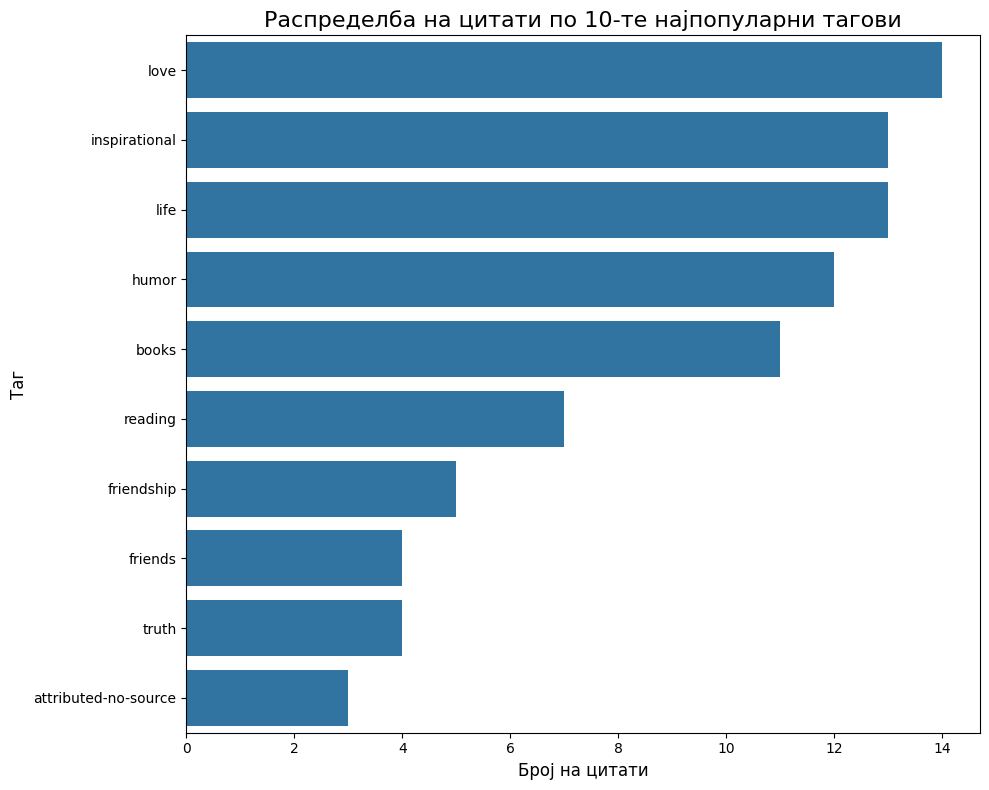

In [2]:
# Проверка дали DataFrame-от има податоци
if not df_quotes.empty:
    
    # --- 1. Наоѓање на топ 10 најкористени тагови ---
    # .value_counts() ги брои уникатните вредности
    # .nlargest(10) ги зема првите 10
    # .index ги зема нивните имиња (таговите)
    top_10_tags = df_quotes['tag'].value_counts().nlargest(10).index
    
    print(f"\nТоп 10 тагови:\n{top_10_tags.to_list()}")
    
    # --- 2. Филтрирање на DataFrame-от ---
    # Го чуваме само редовите кои припаѓаат на топ 10 таговите
    df_top10 = df_quotes[df_quotes['tag'].isin(top_10_tags)]
    
    # --- 3. Креирање на визуелизација ---
    plt.figure(figsize=(10, 8)) # Поголема фигура за подобра читливост
    
    # Користиме 'y='tag'' за да креираме хоризонтален бар-чарт
    # 'order=top_10_tags' ги подредува од најпопуларен кон најмалку популарен
    sns.countplot(
        data=df_top10, 
        y='tag', 
        order=top_10_tags
    )
    
    plt.title('Распределба на цитати по 10-те најпопуларни тагови', fontsize=16)
    plt.xlabel('Број на цитати', fontsize=12)
    plt.ylabel('Таг', fontsize=12)
    plt.tight_layout() # Автоматски ги прилагодува маргините
    plt.show()

else:
    print("Нема податоци за визуелизација.")